# Plotting and Visualization

## A Brief matplotlib API Primer

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
%matplotlib inline

### Figures and Subplots

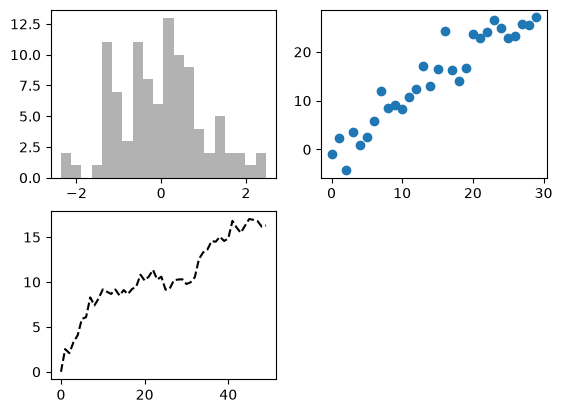

In [16]:
# matplotlib adalah library plotting yang digunakan untuk membuat visualisasi data dalam bentuk grafik. Library ini sangat fleksibel dan dapat digunakan untuk membuat berbagai jenis grafik
# untuk membuat bingkai, kita gunakan fungsi plt.figure()
fig = plt.figure()
# kita bisa menambahkan subplot ke dalam bingkai dengan menggunakan fungsi add_subplot()
ax1 = fig.add_subplot(2, 2, 1) # menghasilkan subplot dengan luas 2x2 dan menempatkan subplot pada posisi pertama
ax2 = fig.add_subplot(2, 2, 2) # menghasilkan subplot dengan luas 2x2 dan menempatkan subplot pada posisi kedua
ax3 = fig.add_subplot(2, 2, 3) # menghasilkan subplot dengan luas 2x2 dan menempatkan subplot pada posisi ketiga
# misal kita ingin menampilkan grafik gari di ax3, kita akan menggunakan fungsi plot() dan memberikan data yang ingin ditampilkan
ax3.plot(np.random.standard_normal(50).cumsum(), color='black', linestyle='dashed')
# akan menampilkan grafik garis dengan data acak dengan warna hitam dan garis putus-putus.
ax1.hist(np.random.standard_normal(100), bins=20, color="black", alpha=0.3)
# akan menampilkan histogram dengan data acak dengan warna hitam dan transparansi 0.3
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.standard_normal(30))
# akan menampilkan scatter plot dengan data acak        

#### berikut argumen subplot yang bisa digunakan:
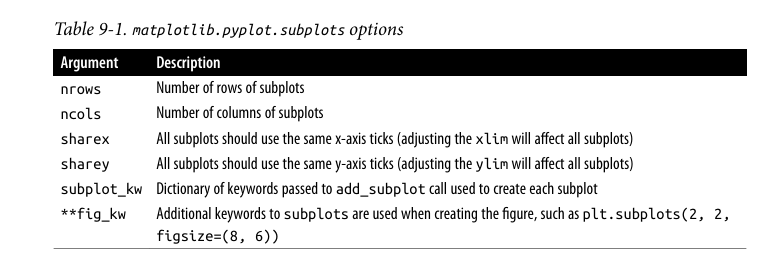

### Ticks, Labels, and Legends

Text(0.5, 0, 'Stages')

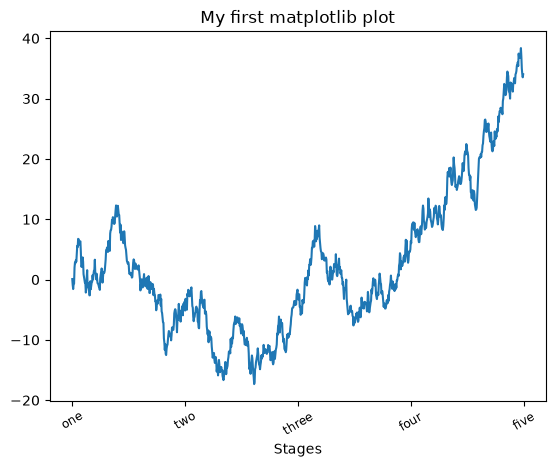

In [19]:
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum());
# bila ingin mengubah titik data kita bisamenggunakan set_xticks() atau set_yticks() untuk mengubah titik data pada sumbu x atau y. Kita juga bisa menggunakan set_xticklabels() atau set_yticklabels()
# untuk mengubah label pada titik data pada sumbu x atau y. Kita juga bisa menggunakan set_xlabel() atau set_ylabel()
# untuk menambah judul kita bisa menggunakan set_title()
ticks = ax.set_xticks([0, 250, 500, 750, 1000])
labels = ax.set_xticklabels(['one', 'two', 'three', 'four', 'five'], rotation=30, fontsize='small')
ax.set_title('My first matplotlib plot')
ax.set_xlabel('Stages')

### Saving Plots to File

#### Untuk menyimpan plot ke file, kita bisa menggunakan fungsi savefig() dari objek Figure. Kita bisa menentukan nama file dan format file yang diinginkan. Contoh:
```python
fig.savefig('my_plot.png')
```
#### berikut argumen savefig() yang bisa digunakan:
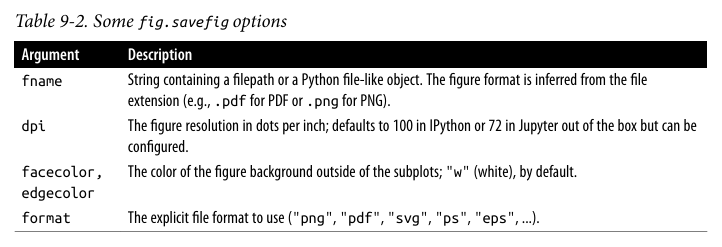

## Plotting with pandas and seaborn
### mathplolib sebenarnya adalah tool level rendah untuk membuat visualisasi data, sehingga kita bisa menggunakan library lain seperti pandas dan seaborn yang dibangun di atas matplotlib untuk membuat visualisasi data yang lebih mudah dan cepat.

### Line plots

<Axes: >

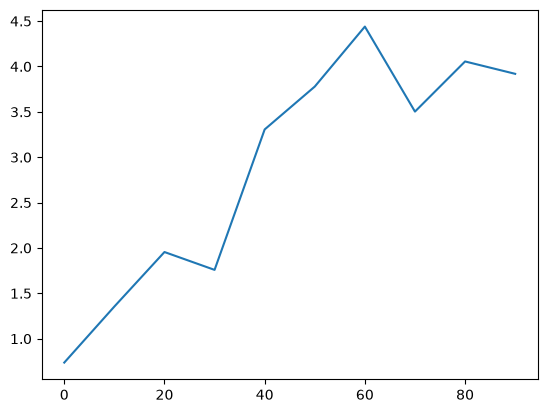

In [21]:
# series dan dataframe juga memiliki fungsi plot() yang dapat digunakan untuk membuat visualisasi data.
# secara default, fungsi plot() akan membuat grafik garis
s = pd.Series(np.random.standard_normal(10).cumsum(), index=np.arange(0, 100, 10))
s.plot()

#### berikut argumen yang bisa diterma plot() pada series:
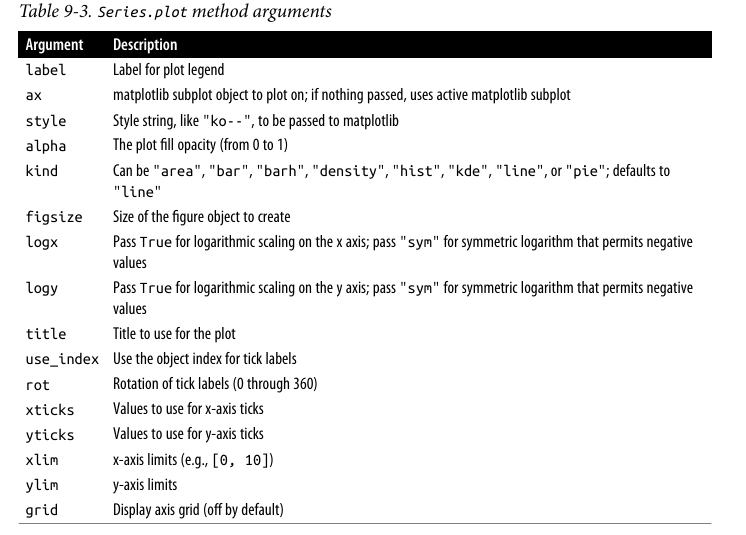

<Axes: >

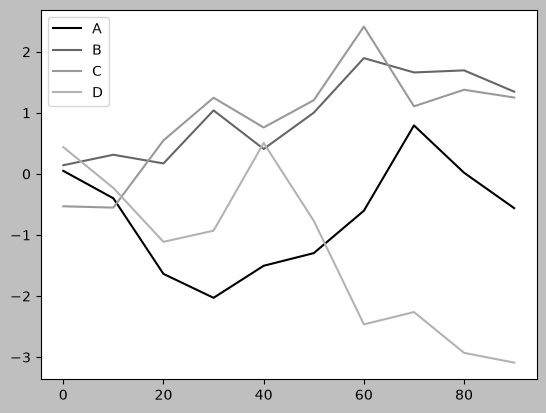

In [22]:
# plot dataframe otomatis akan membuat grafik garis untuk setiap kolom dataframe dan legendnya
df =  df = pd.DataFrame(np.random.standard_normal((10, 4)).cumsum(0),
                        columns=["A", "B", "C", "D"],
                        index=np.arange(0, 100, 10))
plt.style.use('grayscale')
df.plot()

#### berikut argumen plot() yang bisa digunakan pada dataframe:
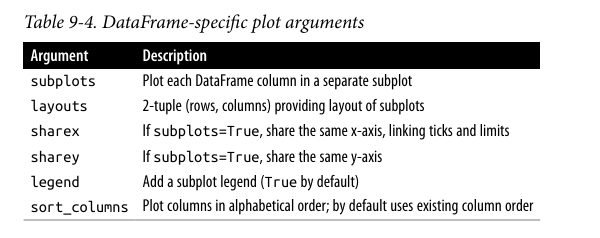

### Bar plots

<Axes: >

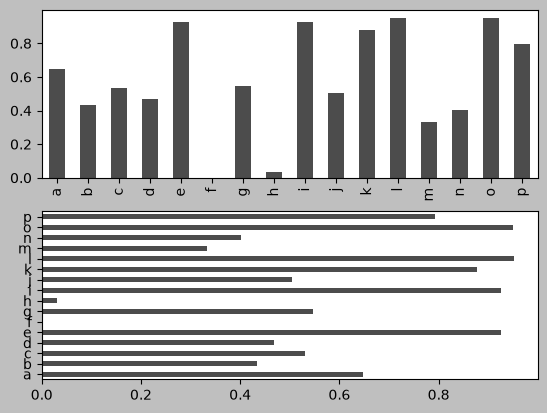

In [ ]:
# kita bisa menampilkan grafik batang dengan pandas menggunkan bar() dan barh() untuk grafik batang horizontal
# bar plot berfungsi untuk displays the frequency or mean of groups using rectangular bars
# index akan menjadi label pada sumbu x dan nilai akan menjadi tinggi batang pada grafik batang vertikal, sedangkan pada grafik batang horizontal index akan menjadi label pada sumbu y dan nilai akan menjadi panjang batang pada grafik batang horizontal
fig, axes = plt.subplots(2, 1)
data = pd.Series(np.random.uniform(size=16), index=list("abcdefghijklmnop"))
data.plot.bar(ax=axes[0], color="black", alpha=0.7)
data.plot.barh(ax=axes[1], color="black", alpha=0.7)

Genus         A         B         C         D
one    0.348318  0.697748  0.940043  0.448498
two    0.822024  0.106968  0.531454  0.799758
three  0.620376  0.211026  0.566460  0.943502
four   0.656925  0.948894  0.097625  0.872557
five   0.184088  0.922060  0.638134  0.809980
six    0.379235  0.002011  0.402201  0.930792


<Axes: >

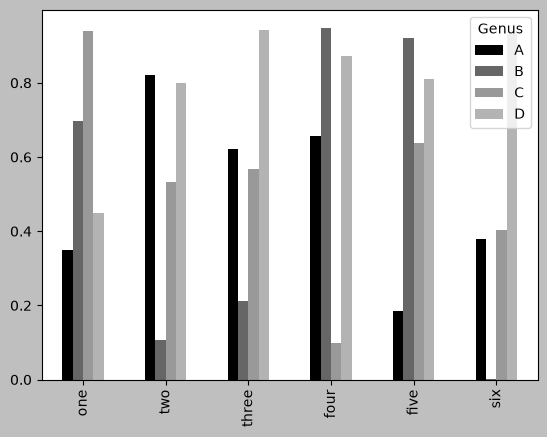

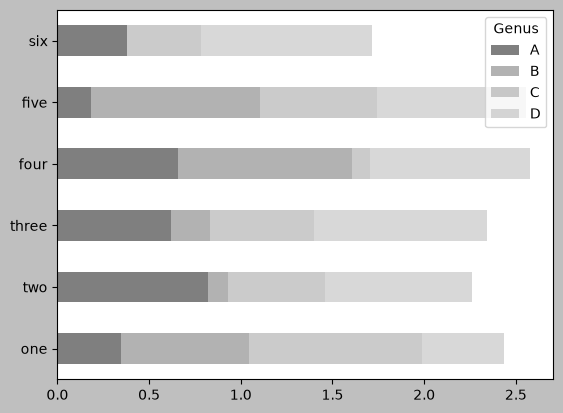

In [ ]:
# pada dataframe, tiap baris akan di group menjadi batang yang berdekatan, sehingga kita bisa membandingkan nilai tiap kolom pada tiap baris. Kita juga bisa menampilkan grafik batang horizontal dengan menggunakan barh()
df = pd.DataFrame(np.random.uniform(size=(6, 4)),
                  index=["one", "two", "three", "four", "five", "six"],
                    columns=pd.Index(["A", "B", "C", "D"], name="Genus"))
print(df)
df.plot.bar()
# kita bisa membuat batang yang saling menumpuk dengan menggunakan argumen stacked=True
df.plot.barh(stacked=True, alpha=0.5)
# A useful recipe for bar plots is to visualize a Series’s value frequency
# using value_counts: s.value_counts().plot.bar()

   total_bill   tip smoker  day    time  size   tip_pct
0       16.99  1.01     No  Sun  Dinner     2  0.063204
1       10.34  1.66     No  Sun  Dinner     3  0.191244
2       21.01  3.50     No  Sun  Dinner     3  0.199886
3       23.68  3.31     No  Sun  Dinner     2  0.162494
4       24.59  3.61     No  Sun  Dinner     4  0.172069


<Axes: xlabel='tip_pct', ylabel='day'>

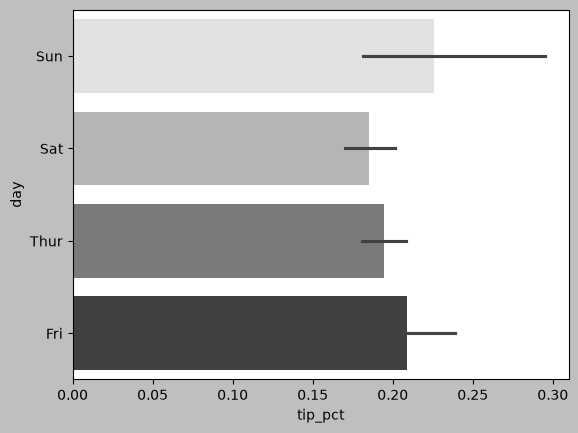

In [45]:
# untuk data yang perlu di agregasi dan summarize sebelum divisualisasikan, akan lebih simpel menggunakan seaborn
tips = pd.read_csv("examples/tips.csv")
tips["tip_pct"] = tips["tip"] / (tips["total_bill"] - tips["tip"])
print(tips.head())
sns.barplot(x="tip_pct", y="day", data=tips, orient="h", hue="day", palette="Greys")

<Axes: xlabel='tip_pct', ylabel='day'>

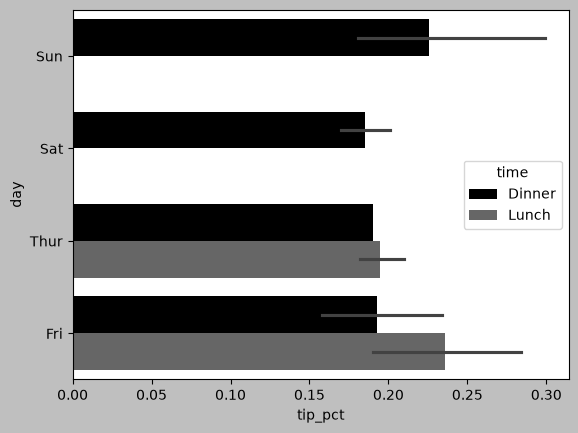

In [43]:
# anda juga bisa mensplit data menjadi beberapa kategori
sns.barplot(x="tip_pct", y="day", hue="time", data=tips, orient="h")

#### kita bisa menganti penampilan dan color palette dengan:
```python
sns.set(style="whitegrid", palette="pastel", color_codes=True)
```

### Histograms and Density Plots

<Axes: ylabel='Frequency'>

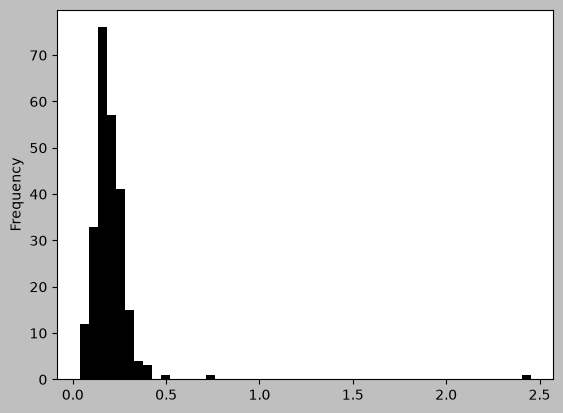

In [ ]:
# pndas juga menyediakan fungsi plot.hist() untuk menampilkan histogram dari data. Kita bisa mengatur jumlah bin dengan argumen bins
# histogram dan density plot berfungsi untuk to visualize the distribution of continuous numeric data. Specifically, they display data shape, center, and spread.
tips["tip_pct"].plot.hist(bins=50)

<Axes: ylabel='Density'>

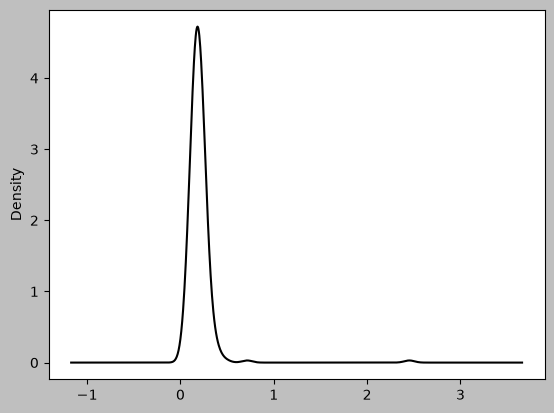

In [ ]:
# pandas juga menyediakan grafik density plot dengan menggunakan fungsi plot.density(). Kita bisa mengatur jumlah bin dengan argumen bins
tips["tip_pct"].plot.density()

<Axes: ylabel='Density'>

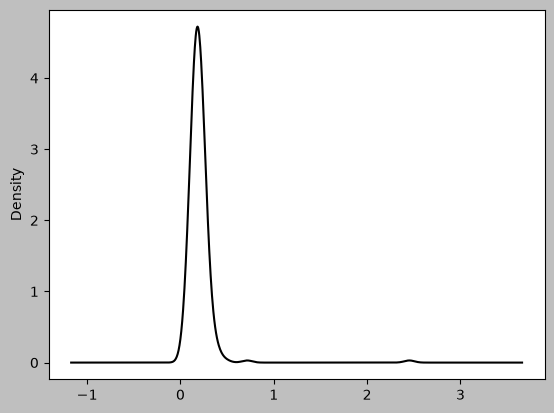

In [48]:
# atau plot.kde() untuk menampilkan grafik density plot juga
tips["tip_pct"].plot.kde()

<Axes: ylabel='Count'>

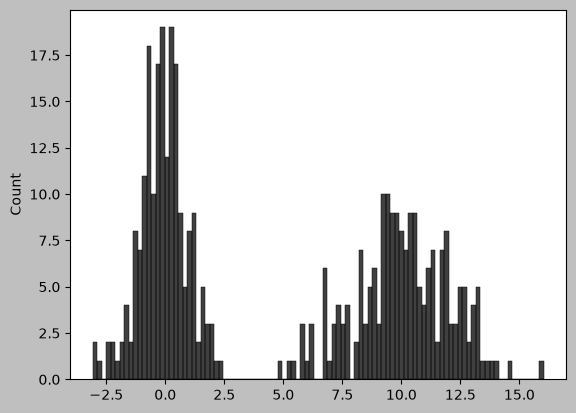

In [49]:
# dengan seaborn kita bisa menampilkan histogram dan density plot dengan lebih mudah. Kita bisa menggunakan fungsi sns.histplot() untuk menampilkan histogram dan density plot sekaligus
comp1 = np.random.standard_normal(200)
comp2 = 10 + 2 * np.random.standard_normal(200)
values = pd.Series(np.concatenate([comp1, comp2]))
sns.histplot(values, bins=100, color="black")

### Scatter or Point Plots

In [51]:
# Scatter or Point Plots berguna untuk melihat pola hubungan (korelasi) antara dua variabel numerik.
macro = pd.read_csv("examples/macrodata.csv")
data = macro[["cpi", "m1", "tbilrate", "unemp"]]
trans_data = np.log(data).diff().dropna()
trans_data.tail()

,cpi,m1,tbilrate,unemp
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339
202,0.008894,0.012202,-0.405465,0.042560


Text(0.5, 1.0, 'Changes in log(m1) versus log(unemp)')

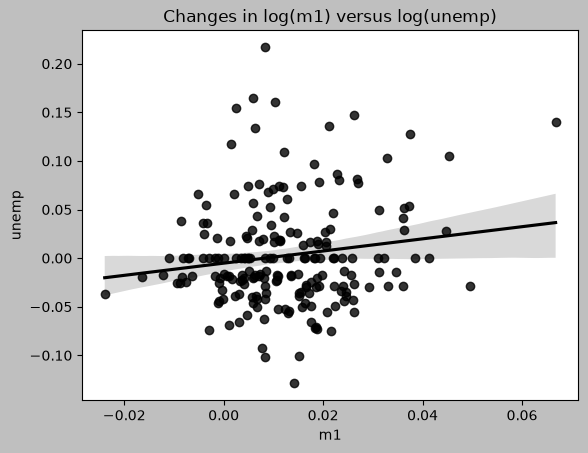

In [53]:
# di seaborn, kita bisa gunakan regplot() untuk menampilkan scatter plot dengan garis regresi linear. Kita bisa mengatur argumen fit_reg=False untuk menonaktifkan garis regresi linear
ax = sns.regplot(x="m1", y="unemp", data=trans_data)
ax.set_title("Changes in log(m1) versus log(unemp)")

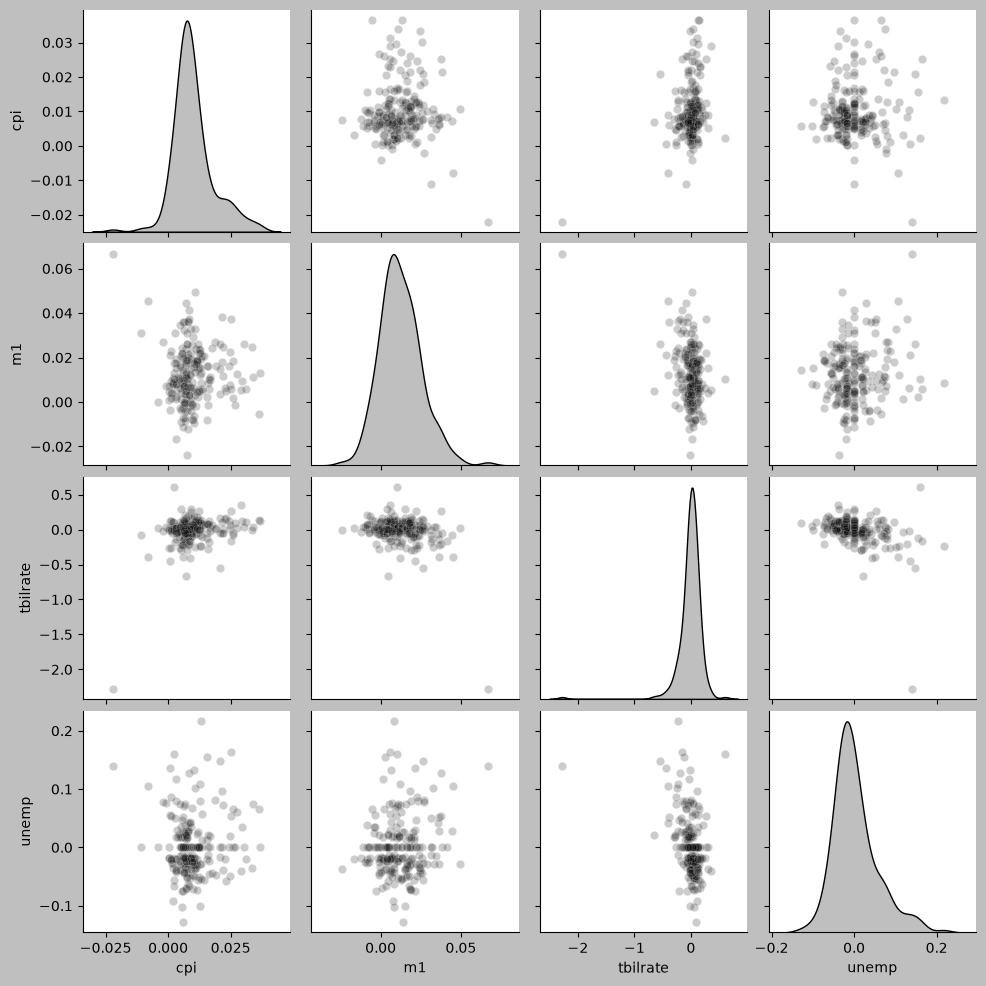

In [54]:
# kita juga bisa membuat scatter plot matrix antar variabel numerik dengan menggunakan fungsi sns.pairplot(). Kita bisa mengatur argumen hue untuk menambahkan warna pada titik data berdasarkan kategori tertentu
sns.pairplot(trans_data, diag_kind="kde", plot_kws={"alpha": 0.2})

### Facet Grids and Categorical Data

<Axes: xlabel='tip_pct', ylabel='day'>

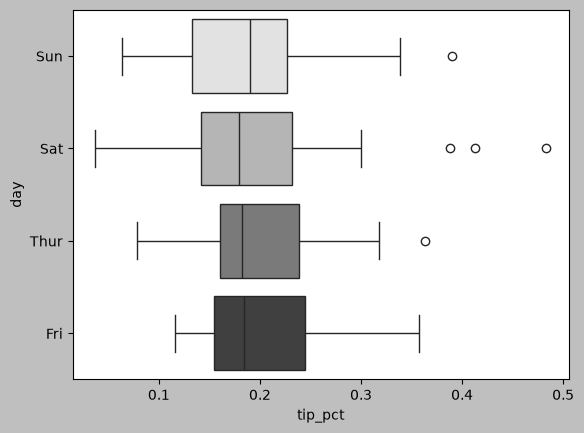

In [56]:
# kita bisa membuat boxplot dari data dengan menggunakan fungsi sns.boxplot()
sns.boxplot(x="tip_pct", y="day", data=tips[tips.tip_pct < 0.5], hue="day", palette="Greys")